# DPA Attack
In this notebook I will try to explain the reasoning behind our code so hopefully if there are any flaws on our reasoning they will be easier to spot :)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import medfilt
from scipy.ndimage import gaussian_filter1d
from cryptography.hazmat.backends import default_backend
from cryptography.hazmat.primitives.ciphers import Cipher, algorithms, modes

### The plot_traces function

In [3]:
def plot_traces(traces):
    plt.figure(figsize=(12, 6))
    plt.plot(traces[0], label='Traces')
    plt.legend()
    plt.show()

### The apply_filters function

This function processes a set of traces by applying two types of filters: a median filter and a Gaussian filter. 
The function first adjusts the size of the median filter kernel to ensure it is suitable for the length of the traces. If the kernel size is even, it increments it by 1 to make it odd, since the median filter requires an odd kernel size. If the adjusted kernel size is greater than 1, the function applies a median filter to each trace. 

The median filter helps to remove noise by replacing each point in the trace with the median of the neighboring points defined by the kernel size. If the gaussian_sigma parameter is greater than 0, the function then applies a Gaussian filter to the traces. The Gaussian filter smooths the traces by averaging each point with its neighbors, with the amount of smoothing controlled by the sigma parameter.

In [4]:
def apply_filters(traces, median_kernel=3, gaussian_sigma=1):
    adjusted_kernel = min(median_kernel, traces.shape[1])
    if adjusted_kernel % 2 == 0:
        adjusted_kernel += 1
    print(f"Applying median filter with kernel_size={adjusted_kernel}")
    
    if adjusted_kernel > 1:
        traces = np.array([medfilt(trace, kernel_size=adjusted_kernel) for trace in traces])
    if gaussian_sigma > 0:
        traces = gaussian_filter1d(traces, sigma=gaussian_sigma, axis=1)
    return traces

### Loading and filtering data

Applying median filter with kernel_size=3


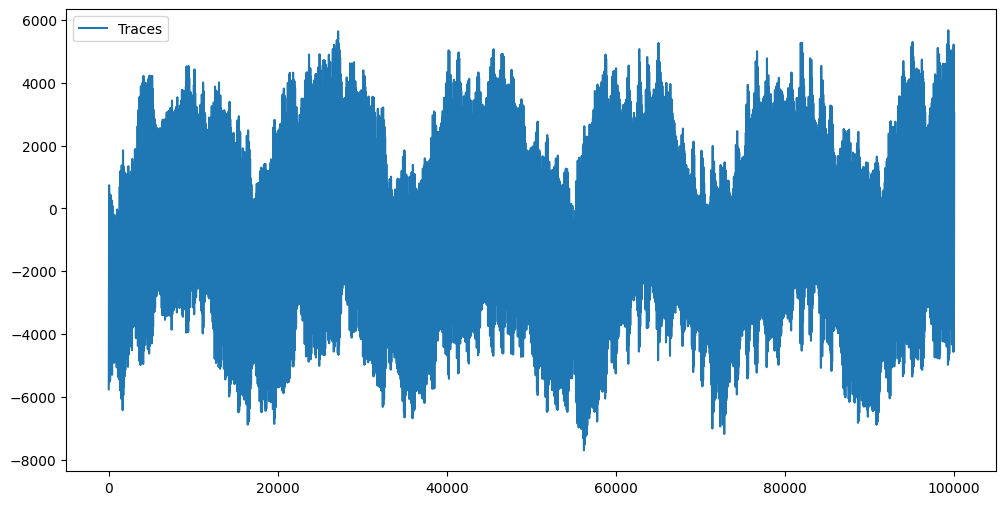

In [5]:
traces_path = 'first-round_decipher_traces.npy'
plaintext_path = 'first-round_decipher_plaintexts.npy'
ciphertext_path = 'first-round_decipher_ciphertexts.npy'

traces = np.load(traces_path)
plaintext = np.load(plaintext_path)
ciphertext = np.load(ciphertext_path)

median_kernel = 3
gaussian_sigma = 1
filtered_traces = apply_filters(traces, median_kernel, gaussian_sigma)

plot_traces(filtered_traces)

### The hamming_weight function

In [6]:
def hamming_weight(n):
    weight = 0
    while n:
        weight += n & 1
        n >>= 1
    return weight


def vhamming_weight(array):
    return np.vectorize(hamming_weight)(array)

### The perform_DPA function

In this function we are going to use ciphertext and the inverse_sbox since the provided traces are for the first round on the decipher process.

The objective of this function is to map the power consumption registered on the traces to a hypothetical power consumption. To calculate the hypothetical power consumption we need to calculate an intermediate result based on the AES algorithm. In our script we chose to use the IR after the operation on the Inverse SBOX.

``` python
inverse_sbox[ct ^ hypothesis]
```
Where ct is a byte of ciphertext and hypothesis is the hypothetical value of that byte of the key. We then calculate the hamming weight of each intermediate result to get the hypothetical power consumption

Once we have stored all the hypothetical power consumptions we have to see which better relates to the analyzed traces through an algorithm that divides all the hamming weights in odds and evens, then calculates the average value of each group. After this the hypothesis with the biggest difference between all the average values is the best hypothesis.

In [7]:
def perform_DPA(ciphertext, traces):
    inverse_sbox = [
        0x52, 0x09, 0x6A, 0xD5, 0x30, 0x36, 0xA5, 0x38, 0xBF, 0x40, 0xA3, 0x9E, 0x81, 0xF3, 0xD7, 0xFB,
        0x7C, 0xE3, 0x39, 0x82, 0x9B, 0x2F, 0xFF, 0x87, 0x34, 0x8E, 0x43, 0x44, 0xC4, 0xDE, 0xE9, 0xCB,
        0x54, 0x7B, 0x94, 0x32, 0xA6, 0xC2, 0x23, 0x3D, 0xEE, 0x4C, 0x95, 0x0B, 0x42, 0xFA, 0xC3, 0x4E,
        0x08, 0x2E, 0xA1, 0x66, 0x28, 0xD9, 0x24, 0xB2, 0x76, 0x5B, 0xA2, 0x49, 0x6D, 0x8B, 0xD1, 0x25,
        0x72, 0xF8, 0xF6, 0x64, 0x86, 0x68, 0x98, 0x16, 0xD4, 0xA4, 0x5C, 0xCC, 0x5D, 0x65, 0xB6, 0x92,
        0x6C, 0x70, 0x48, 0x50, 0xFD, 0xED, 0xB9, 0xDA, 0x5E, 0x15, 0x46, 0x57, 0xA7, 0x8D, 0x9D, 0x84,
        0x90, 0xD8, 0xAB, 0x00, 0x8C, 0xBC, 0xD3, 0x0A, 0xF7, 0xE4, 0x58, 0x05, 0xB8, 0xB3, 0x45, 0x06,
        0xD0, 0x2C, 0x1E, 0x8F, 0xCA, 0x3F, 0x0F, 0x02, 0xC1, 0xAF, 0xBD, 0x03, 0x01, 0x13, 0x8A, 0x6B,
        0x3A, 0x91, 0x11, 0x41, 0x4F, 0x67, 0xDC, 0xEA, 0x97, 0xF2, 0xCF, 0xCE, 0xF0, 0xB4, 0xE6, 0x73,
        0x96, 0xAC, 0x74, 0x22, 0xE7, 0xAD, 0x35, 0x85, 0xE2, 0xF9, 0x37, 0xE8, 0x1C, 0x75, 0xDF, 0x6E,
        0x47, 0xF1, 0x1A, 0x71, 0x1D, 0x29, 0xC5, 0x89, 0x6F, 0xB7, 0x62, 0x0E, 0xAA, 0x18, 0xBE, 0x1B,
        0xFC, 0x56, 0x3E, 0x4B, 0xC6, 0xD2, 0x79, 0x20, 0x9A, 0xDB, 0xC0, 0xFE, 0x78, 0xCD, 0x5A, 0xF4,
        0x1F, 0xDD, 0xA8, 0x33, 0x88, 0x07, 0xC7, 0x31, 0xB1, 0x12, 0x10, 0x59, 0x27, 0x80, 0xEC, 0x5F,
        0x60, 0x51, 0x7F, 0xA9, 0x19, 0xB5, 0x4A, 0x0D, 0x2D, 0xE5, 0x7A, 0x9F, 0x93, 0xC9, 0x9C, 0xEF,
        0xA0, 0xE0, 0x3B, 0x4D, 0xAE, 0x2A, 0xF5, 0xB0, 0xC8, 0xEB, 0xBB, 0x3C, 0x83, 0x53, 0x99, 0x61,
        0x17, 0x2B, 0x04, 0x7E, 0xBA, 0x77, 0xD6, 0x26, 0xE1, 0x69, 0x14, 0x63, 0x55, 0x21, 0x0C, 0x7D
    ]

    result = []
    num_samples = traces.shape[1]
    for byte_index in range(16):
        max_total = -1
        index = -1
        for hypothesis in range(256):
            ciphertext_bytes = np.array([ct[byte_index] for ct in ciphertext])
            intermediate = np.array([inverse_sbox[ct ^ hypothesis] for ct in ciphertext_bytes])

            hw = vhamming_weight(intermediate)
            
            zeros = np.zeros(num_samples)
            ones = np.zeros(num_samples)
            counterZ = 0
            counterO = 0
            
            for i, weight in enumerate(hw):
                if weight % 2 == 0:
                    counterZ += 1
                    zeros += traces[i]
                else:
                    counterO += 1
                    ones += traces[i]
            
            if counterZ == 0 or counterO == 0:
                continue

            zeros_average = zeros / counterZ
            ones_average = ones / counterO
            
            max_value = max(abs(zeros_average - ones_average))
            
            if max_value > max_total:
                index = hypothesis
                max_total = max_value

        if index == -1:
            raise Exception(f"No valid key hypothesis found for byte index {byte_index}.")
        result.append(index)
    return result

### The decrypt_text function

In [8]:
def decrypt_text(text, key):
    if isinstance(text, str):
        text = text.encode('utf-8')
    elif isinstance(text, np.ndarray):
        text = bytes(text)

    cipher = Cipher(algorithms.AES(key), modes.ECB(), backend=default_backend())
    decryptor = cipher.decryptor()

    ciphertext = decryptor.update(text) + decryptor.finalize()
    return np.frombuffer(ciphertext, dtype=np.uint8)

### Testing

When we have the key we convert it to the format of the text in ciphertext and plaintext and use it to decrypt a sample and compare it to the expected result, if they are the same the key is correct, if it's not then the key is incorrect.

In [10]:
key = perform_DPA(ciphertext, filtered_traces)
    
print(f"\nFound key: {key}")

key_array = np.array(key, dtype=np.uint8)

decrypted_text = decrypt_text(ciphertext[0], key_array)
print(f"\Encrypted text: {decrypted_text}")

if np.array_equal(decrypted_text, plaintext[0]):
    print("Correct key.")
else:
    print("Incorrect key.")
    print(f"Expected plaintext: {plaintext[0]}")


Found key: [124, 133, 167, 169, 255, 170, 176, 231, 213, 233, 178, 48, 114, 71, 218, 14]
\Encrypted text: [183 239  81 122 202  81 240 214  17 215 120  78 197 154 167 219]
Incorrect key.
Expected plaintext: [193 238 121 253 139  12 241 168  94  37 197  55 155  77  98  95]
